# Simulating on a Par 3 - hole 9 MM

In [144]:
import pandas as pd
import numpy as np
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [145]:
lpga_clubs = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Trackman Fake Data/simulated_lpga_shot_data.csv")
hole_9 = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")

### Selecting Teebox

In [146]:
# to get the centre of shapes
def get_centroid(row):
    shape = wkt.loads(row["WKT"])
    return shape.centroid.coords[0] # returns the x,y coords

# finding furthest teebox
teeboxes = hole_9[hole_9["lie"].str.contains("tee", case = False)]
green = hole_9[hole_9["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green["WKT"])
green_centre = get_centroid(green)
# getting different teeboxes centre
teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column

# distances to green
teeboxes["dist_to_green"] = teeboxes["centroid"].apply(
    # np.array(pt) - np.array(green_centre) -> subtracts the two 2d points, and linalg compute the euclidean distance
    lambda pt: np.linalg.norm(np.array(pt) - np.array(green_centre))
)

longest_teebox = teeboxes.loc[teeboxes["dist_to_green"].idxmax()]
tee_point = longest_teebox["centroid"]


# --- from simulating putting, to define random hole location
def sample_point_on_green(green_shape):
    # get the bounds of the green shape
    minx, miny, maxx, maxy = green_shape.bounds

    while True:
        # randomly generate random coordinate
        x_ball = np.random.uniform(minx, maxx)
        y_ball = np.random.uniform(miny, maxy)
        # check whether point is on green
        if green_shape.contains(Point(x_ball, y_ball)):
            return (x_ball, y_ball)
        
hole = sample_point_on_green(green_shape)

hole = (5, 174)

/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_98839/3202513976.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column
/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_98839/3202513976.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["dist_to_green"] = teeboxes["centroid"].apply(


### Printing Pin Position and Tee Box

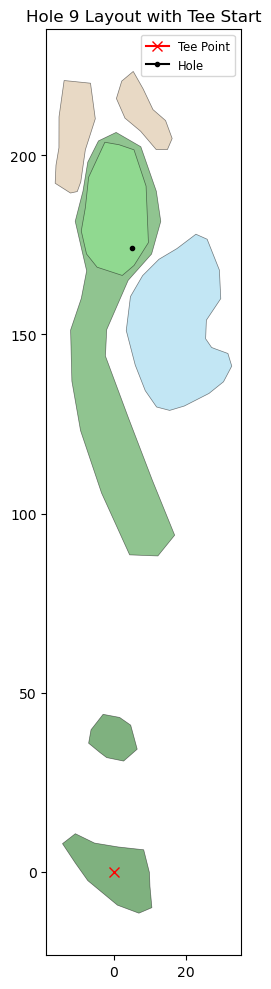

In [147]:
# colors by lie type
lie_colors = {
    "bunker": "tan",
    "fairway": "forestgreen",
    "green": "lightgreen",
    "OB": "lightcoral",
    "rough": "mediumseagreen",
    "tee": "darkgreen",
    "water_hazard": "skyblue"
}

fig, ax = plt.subplots(figsize=(10, 10))

# fill each shape with the appropriate colour
for _, row in hole_9.iterrows():
    geom = wkt.loads(row["WKT"])
    color = lie_colors.get(row["lie"], "lightgrey")

    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)

# mark tee and hole
ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=7, label="Tee Point")
ax.plot(hole[0], hole[1], marker='o', color='black', markersize=3, label="Hole")

ax.set_aspect("equal")
ax.set_title("Hole 9 Layout with Tee Start")
ax.legend(loc='upper right', fontsize="small")
plt.tight_layout()
plt.show()


## Simulating Shots
Rotating and translating LPGA shots

### Rotation Matrices
If have a coordinate with form relative to the aimpoint:
$$(x,y)$$
To rotate it $\theta$ degrees anticlockwise (i.e. left), you multiply with:
$$\text{Rot}_{\theta} = \begin{bmatrix} \cos(\theta) &- \sin(\theta)\\
\sin(\theta) & \cos(\theta)\end{bmatrix}$$

In [148]:
def rotation_translator(x_side, y_carry, angle, starting_point, target):

    # base angle from starting_point to target
    line_to_target = np.array(target) - np.array(starting_point)
    base_angle = np.arctan2(line_to_target[1], line_to_target[0])

    # aiming offset
    theta = -np.radians(angle) + base_angle
    # rotation matrix
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])

    # Rotate shot vector
    original_vec = np.array([x_side, -y_carry])
    rotated_vec = rot_matrix @ original_vec

    # rotating the *rotated vector* into the global frame using base_angle
    global_rot = np.array([
        [np.cos(base_angle), -np.sin(base_angle)],
        [np.sin(base_angle),  np.cos(base_angle)]
    ])
    final_vec = global_rot @ rotated_vec

    # Add tee location
    return tuple(final_vec + np.array(starting_point))

## Offset Angle in Yards -> SOHCAHTOA FOR INTERPRETABILITY
Want to aim at a point:
- distance d (straight line)
- x lateral offset

So via sohcahtoa

$$\theta = \arctan(\frac{x}{d})$$

In [149]:
def yard_offset_to_angle(yards_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.arctan(yards_offset / dis_target)
    return np.degrees(angle_rad)

def angle_offset_to_yard(angle_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.radians(angle_offset)
    offset = np.tan(angle_rad) * dis_target
    return offset

## Interactive Plot to Visualise Different aimpoints

In [ ]:
from ipywidgets import interact, Dropdown, IntSlider

# base distance (to target)
total_distance = np.linalg.norm(np.array(hole) - np.array(tee_point))

# Just for the Drop Down menu
club_order = [
    "Driver", "3-wood", "5-wood", "Hybrid",
    "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron",
    "PW", "50 deg", "54 deg", "60 deg"
]
sorted_clubs = [club for club in club_order if club in lpga_clubs["Club"].unique()]

# Interactive widget with dropdown for irons
@interact(
    club=Dropdown(options=sorted_clubs, value="5 Iron", description="Club:"),
    aim_yards=IntSlider(min=-20, max=20, step=1, value=0, description="Aim (yds):")
)

def plot_rotated_shots(club, aim_yards):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Filter club data
    club_df = lpga_clubs[lpga_clubs["Club"] == club].copy()

    # Convert aim offset in yards to angle in degrees
    angle_rad = np.arctan(aim_yards / total_distance)
    angle_deg = np.degrees(angle_rad)

    # Draw hole
    for _, row in hole_9.iterrows():
        geom = wkt.loads(row["WKT"])
        color = lie_colors.get(row["lie"], "lightgrey")
        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.4)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, fc=color, alpha=0.4)

    # Plot rotated shots
    for _, row in club_df.iterrows():
        x, y = rotation_translator(row["Side"], row["Carry"], angle_deg, tee_point, hole)
        ax.plot(x, y, marker='.', color='blue', alpha=0.6)

    # Tee & hole
    ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=8, label='Tee')
    ax.plot(hole[0], hole[1], marker='o', color='black', markersize=5, label='Hole')

    # --- Plot Aim Line showing the rotated centerline of shot dispersion ---
    aim_direction = np.array(hole) - np.array(tee_point)
    aim_direction_unit = aim_direction / np.linalg.norm(aim_direction)

    # Rotation matrix to rotate the aim line by the aiming angle (clockwise = positive)
    theta = -angle_rad  # negative so positive input rotates clockwise
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated_aim_direction = rot_matrix @ aim_direction_unit

    # Extend from tee point outward by total_distance
    aim_endpoint = np.array(tee_point) + rotated_aim_direction * total_distance

    # Plot the rotated aim line
    ax.plot(
        [tee_point[0], aim_endpoint[0]],
        [tee_point[1], aim_endpoint[1]],
        linestyle="--",
        color="red",
        label="Aim Point"
    )
    
        # Grid overlay every 5 yards
    ax.set_xticks(np.arange(-40, 40, 10), minor=False)
    ax.set_yticks(np.arange(-50, 251, 10), minor=False)

    ax.grid(which='major', color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
    ax.set_title(f"{club} | Aim {aim_yards} yd, {round(angle_deg, 2)}°")
    ax.set_aspect("equal")
    ax.legend()
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Club:', index=5, options=('Driver', '3-wood', '5-wood', 'Hybrid', …

# Simulating, the mathematical way ;)
## Fit Bivariate Gaussian to LPGA Shot Data
Define:
- $X$ -> Side (yards left/right)
- $Y$ -> Carry (forward)

From LPGA shots with a given $\mathcal{c}$:
Compute, gaussian distribution:
$$\mu_{\mathcal{c}} = \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \Sigma_{\mathcal{c}} = \begin{bmatrix} \sigma^2_{X} & \rho\sigma_X\sigma_Y \\
\rho\sigma_X\sigma_Y & \sigma^2_{Y}\end{bmatrix}$$

## Sampling Shots from Gaussian
Simulate $N$ shots
$$\vec{s} \sim \mathcal{N}(\mu_\mathcal c, \Sigma_ \mathcal c)$$

## Rotate and Translate to Hole setting

Let:

* $\vec{v} = \text{unit vector from tee to pin}$
* $\theta = \arctan(\text{aim}_\text{offset} / \text{distance to pin})$

Then:

* Want to rotate each shot $\vec{s}_i$ by angle $\theta$ (clockwise = +)
* Translate from tee location:

$$
\vec{p}_i = \text{Tee} + R(\theta) \cdot \vec{s}_i
$$

## Evaluate Strokes-to-Hole for Each Landing Point

Define function:

$$
\text{ExpectedStrokes}(\vec{p}_i) =
\begin{cases}
\text{GPR-putting} & \text{if } \vec{p}_i \in \text{green} \\
\text{Broadie interpolation} & \text{if } \vec{p}_i \in \text{fairway, rough, bunker} \\
\text{Drop + Broadie} & \text{if } \vec{p}_i \in \text{water}
\end{cases}
$$

## Summarise Results

From values $\{ \text{ES}_i \}_{i=1}^N$, compute:

* $\mathbb{E}[\text{Strokes}] = \frac{1}{N} \sum_i \text{ES}_i$
* $\text{95\% CI} = \text{quantile range of } \{ \text{ES}_i \}$



# Bivariate LPGA distribution
Computing and Plotting for Visual Purpose

## Simulating Shots

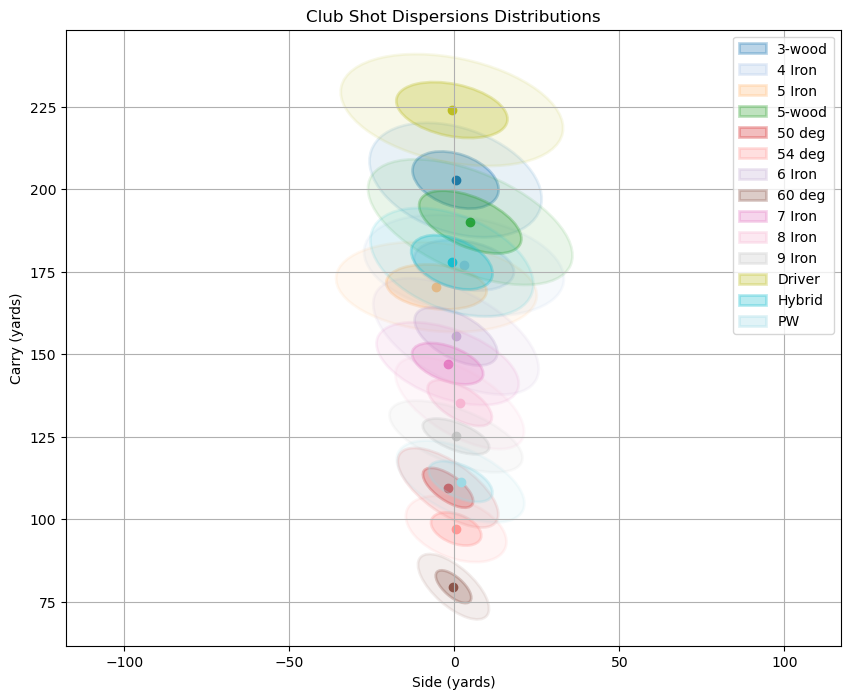

In [151]:
from matplotlib.patches import Ellipse

# side = x, carry = y
club_distributions = {}

for club, group in lpga_clubs.groupby("Club"):
    mean = group[["Side", "Carry"]].mean().to_numpy() 
    cov = np.cov(group[["Side", "Carry"]].T)         

    club_distributions[club] = {
        "mean": mean,
        "cov": cov
    }

def get_club_distribution(club):
    return club_distributions[club]["mean"], club_distributions[club]["cov"]

def plot_all_club_distributions(club_distributions):
    fig, ax = plt.subplots(figsize=(10, 8))
    colours = plt.cm.tab20(np.linspace(0, 1, len(club_distributions)))

    for (club, stats), color in zip(club_distributions.items(), colours):
        mu, cov = stats["mean"], stats["cov"]

        # align axes along eigen vectors
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]

        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)

        ellipse_1 = Ellipse(xy=mu, width=width, height=height, angle=angle,
                          edgecolor=color, fc=color, lw=2, label=club, alpha = .3)
        ellipse_2 = Ellipse(xy=mu, width=2*width, height=2*height, angle=angle,
                          edgecolor=color, fc=color, lw=2, alpha = .1)
        ax.add_patch(ellipse_1)
        ax.add_patch(ellipse_2)
        ax.scatter(*mu, color=color, marker='o')

    ax.set_title("Club Shot Dispersions Distributions")
    ax.set_xlabel("Side (yards)")
    ax.set_ylabel("Carry (yards)")
    ax.axis('equal')
    ax.grid(True)
    ax.legend()
    plt.show()

# Call it
plot_all_club_distributions(club_distributions)


### Shot Evaluation:

For each simulated shot landing point $(x, y)$:

####  If the point is on the green:

* GPR and Modifier Used to Evaluate

#### If point in fairway / rough / bunker:

* Use interpolation from Broadie’s expected strokes tables
* * for now

#### If it lands in water:

* Trace the line from tee to the ball
* Find first intersection with the water polygon
* Compute drop point there and re-evaluate expected strokes from drop point

# Defining Polygons for Simulation / Id of Ball Location

In [152]:
from shapely.geometry import Point

# parsing all shapes
hole_9["shape"] = hole_9["WKT"].apply(wkt.loads)

# Other lies
def get_polygons(df, match):
    return df[df["lie"].str.contains(match, case=False)]["shape"].tolist()

fairway_polygons = get_polygons(hole_9, "fairway")
rough_polygons = get_polygons(hole_9, "rough")
bunker_polygons = get_polygons(hole_9, "bunker")
water_polygons = get_polygons(hole_9, "water")
green_polygon = green_shape 

def get_lie_category(point):
    pt = Point(point)

    if green_polygon.contains(pt):
        return "green"
    if any(poly.contains(pt) for poly in fairway_polygons):
        return "fairway"
    if any(poly.contains(pt) for poly in bunker_polygons):
        return "bunker"
    if any(poly.contains(pt) for poly in rough_polygons):
        return "rough"
    if any(poly.contains(pt) for poly in water_polygons):
        return "water"
    return "unknown"

# Modular functions to compute expectation from different lies

In [181]:
from expectedputts import raw_gpr_pred, tier_multiplier, side_slope_multiplier, uphill_downhill_multiplier
from scipy.interpolate import interp1d
from shapely.geometry import LineString

broadie_data = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/broadiedata/strokes_by_lie_yards_broadie.csv")

# interpolators per lie
broadie_interpolators = {}

# Rename for convenience
broadie_data = broadie_data.rename(columns={"Distance (yards)": "distance"})

# Pivot to Long
broadie_long = broadie_data.melt(id_vars="distance", var_name="lie", value_name="strokes")

# Make lie lowercase
broadie_long["lie"] = broadie_long["lie"].str.lower()


for lie, group in broadie_long.groupby("lie"):
    # Sort by distance to ensure monotonic x
    group = group.sort_values("distance")
    f = interp1d(
        group["distance"], group["strokes"],
        kind="linear", fill_value="extrapolate"
    )
    broadie_interpolators[lie.lower()] = f

def interpolate_broadie(lie, distance):
    lie = lie.lower()
    if lie not in broadie_interpolators:
        raise ValueError(f"No interpolator found for lie: {lie}")
    return broadie_interpolators[lie](distance)

# Green -> GPR and Slope Modifier
def evaluate_on_green(point, target):
    mu, sigma = raw_gpr_pred(point, target)

    # Get multipliers
    tier_mult = tier_multiplier(point, target)
    side_mult = side_slope_multiplier(point, target)
    hill_mult = uphill_downhill_multiplier(point, target)

    # Combine and adjust
    total_mean_mult = tier_mult * side_mult * hill_mult
    mu_adj = mu * total_mean_mult

    total_std_mult = 0.85 * total_mean_mult + 0.15
    sigma_adj = sigma * total_std_mult

    return mu_adj


# Any location but green -> INTERPOLATE FROM BROADIE DATA
def evaluate_broadie(point, target, lie):
    dist = np.linalg.norm(np.array(point) - np.array(target))
    return interpolate_broadie(lie, dist)

# Finding water drop location:
def get_water_intersection(starting_point, ball_in_water):
    shot_line = LineString([starting_point, ball_in_water])
    closest_intersection = None
    min_dist = float("inf")

    # loop through all the water objects
    for poly in water_polygons:

        # check if the shot line intersects the water polygon's boundary
        intersection = shot_line.intersection(poly.boundary)

        # if no intersection, we skip this water polygon since it's the wrong one
        if intersection.is_empty:
            continue

        # if the intersection is a single point (will mostly always be
        elif isinstance(intersection, Point):
            # compute distance from starting point to the intersection
            dist_from_start = Point(starting_point).distance(intersection)
            # keep the point if it's the closest so far
            if dist_from_start < min_dist:
                min_dist = dist_from_start
                closest_intersection = intersection

        # if intersection is multiple points, winding river etc
        else:
            for pt in intersection.geoms:
                # Only process Point geometries
                if isinstance(pt, Point):
                    dist_from_start = Point(tee_point).distance(pt)
                    # Update closest if it's nearer to tee
                    if dist_from_start < min_dist:
                        min_dist = dist_from_start
                        closest_intersection = pt

    # If we found an intersection, return its (x, y) as a tuple
    if closest_intersection:
        return (closest_intersection.x, closest_intersection.y)
    else:
        # Otherwise, no water was intersected
        return None

# Ball falls in water -> simulate drop + calculate expectation from drop location + 1
def evaluate_water_hazard(starting_point, point, target):
    drop_location = get_water_intersection(starting_point, point)
    if drop_location:
        if green_polygon.contains(Point(drop_location)):
            return 1 + evaluate_on_green(drop_location)
        else:
            return 1 + evaluate_broadie(drop_location, target, "rough")
    return np.nan


def evaluate_shot(point, starting_point, target):
    lie = get_lie_category(point)

    if lie == "green":
        return evaluate_on_green(point, target)
    elif lie == "fairway":
        return evaluate_broadie(point, target, "fairway")
    elif lie == "rough":
        return evaluate_broadie(point, target, "rough")
    elif lie == "bunker":
        return evaluate_broadie(point, target, "sand")
    elif lie == "water":
        return evaluate_water_hazard(point, starting_point, target)
    else:
        return evaluate_broadie(point, target, "rough")



def simulate_and_evaluate(starting_point, target, club, aim_offset=0, n_samples=20):
    mu, cov = get_club_distribution(club)
    raw_samples = np.random.multivariate_normal(mu, cov, size=n_samples)

    # Rotation setup
    total_distance = np.linalg.norm(np.array(target) - np.array(starting_point))
    angle_rad = np.arctan(aim_offset / total_distance)
    angle_deg = np.degrees(angle_rad)

    evaluated = []
    for shot in raw_samples:
        x_rot, y_rot = rotation_translator(shot[0], shot[1], angle_deg, starting_point, target)
        es = evaluate_shot((x_rot, y_rot), starting_point, target)
        evaluated.append({
            "original_shot": (shot[0], shot[1]),
            "landing_point": (x_rot, y_rot),
            "expected_strokes": es
        })
        
   # Compute mean and variance of non-NaN strokes
    all_strokes = [d["expected_strokes"] for d in evaluated if not np.isnan(d["expected_strokes"])]
    mean_es = np.mean(all_strokes) if all_strokes else np.nan
    var_es = np.var(all_strokes) if all_strokes else np.nan

    return {
        "evaluated_shots": evaluated,
        "mean_expected_strokes": mean_es,
        "variance_expected_strokes": var_es
    }

# Plotting the Evaluated Shots

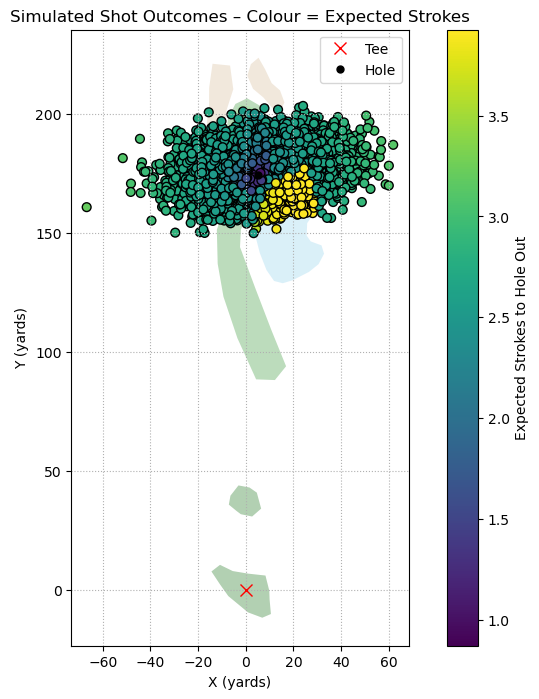

In [194]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Run simulation
results = simulate_and_evaluate(tee_point, hole, "4 Iron", aim_offset=0, n_samples=10000)
evaluated_shots = results["evaluated_shots"]

# Extract data
xs = [r["landing_point"][0] for r in evaluated_shots]
ys = [r["landing_point"][1] for r in evaluated_shots]
strokes = [r["expected_strokes"] for r in evaluated_shots]

# Create a color map based on strokes
norm = Normalize(vmin=min(strokes), vmax=max(strokes))
cmap = cm.viridis

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Optional: draw hole geometry
for _, row in hole_9.iterrows():
    geom = wkt.loads(row["WKT"])
    color = lie_colors.get(row["lie"], "lightgrey")
    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, fc=color, alpha=0.3)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, fc=color, alpha=0.3)

# Plot shots with colour-coded expected strokes
sc = ax.scatter(xs, ys, c=strokes, cmap=cmap, norm=norm, s=40, edgecolor='k')

# Tee and hole
ax.plot(tee_point[0], tee_point[1], 'rx', label='Tee', markersize=8)
ax.plot(hole[0], hole[1], 'ko', label='Hole', markersize=5)

# Colour bar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Expected Strokes to Hole Out")

ax.set_title("Simulated Shot Outcomes – Colour = Expected Strokes")
ax.set_xlabel("X (yards)")
ax.set_ylabel("Y (yards)")
ax.set_aspect('equal')
ax.legend()
plt.grid(True, linestyle=':')
plt.show()


# Finding the Optimal Combo

In [ ]:
def simulate_all(starting_point, hole, clubs, aim_range=(-20, 20), aim_step=1, n_samples=20):
    start, stop = aim_range
    aim_points = range(start, stop + 1, aim_step) 

    club_results = {}

    for club in clubs:
        club_results[club] = []  # initialise list to store each aim's result

        for aim in aim_points:
            sim = simulate_and_evaluate(starting_point, hole, club, aim_offset=aim, n_samples=n_samples)
            club_results[club].append({
                "aim_offset": aim,
                "mean": sim["mean_expected_strokes"],
                "variance": sim["variance_expected_strokes"],
                "shots": sim["evaluated_shots"]
            })

    return club_results

# Finds the single best club/aimpoint combination with the lowest mean expected strokes.
def optimal_club_aimpoint_combination(club_results):
    best = None
    best_score = float('inf')
    
    for club, sims in club_results.items():
        for sim in sims:
            if sim["mean"] < best_score:
                best_score = sim["mean"]
                best = {"club": club, "aim_offset": sim["aim_offset"], "mean": sim["mean"], "variance": sim["variance"]}
    return best

# Averages all aimpoint combinations for each club and returns the club with the lowest average.
def optimal_club_ignoring_aim(club_results):
    summary = []
    for club, sims in club_results.items():
        means = [sim["mean"] for sim in sims if not np.isnan(sim["mean"])]
        avg_mean = np.mean(means) if means else np.nan
        summary.append((club, avg_mean))
    
    best = min(summary, key=lambda x: x[1])
    return {"club": best[0], "avg_mean": best[1]}

# For each club, returns the best aimpoint (with lowest mean expected strokes).
def optimal_aimpoint_per_club(club_results):
    results = {}
    for club, sims in club_results.items():
        best_aim = min(sims, key=lambda sim: sim["mean"] if not np.isnan(sim["mean"]) else float('inf'))
        results[club] = {"aim_offset": best_aim["aim_offset"], "mean": best_aim["mean"]}
    return results


In [195]:
clubs = [
    "Driver", "3-wood", "5-wood", "Hybrid",
    "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron",
    "PW", "50 deg", "54 deg", "60 deg"
]

all_clubs_res = simulate_all(tee_point, hole, clubs=clubs, n_samples = 100)

print(optimal_club_aimpoint_combination(all_clubs_res))
print(optimal_club_ignoring_aim(all_clubs_res))
print(optimal_aimpoint_per_club(all_clubs_res))



{'club': 'Hybrid', 'aim_offset': -9, 'mean': 2.248068558545666, 'variance': 0.2608670839820949}
{'club': '4 Iron', 'avg_mean': 2.5448201272315276}
{'Driver': {'aim_offset': -2, 'mean': 2.983267719120635}, '3-wood': {'aim_offset': -1, 'mean': 2.673934421890103}, '5-wood': {'aim_offset': 1, 'mean': 2.4219874525982834}, 'Hybrid': {'aim_offset': -9, 'mean': 2.248068558545666}, '4 Iron': {'aim_offset': -8, 'mean': 2.349205097931963}, '5 Iron': {'aim_offset': -20, 'mean': 2.4117554726005865}, '6 Iron': {'aim_offset': -20, 'mean': 2.716965810925533}, '7 Iron': {'aim_offset': -20, 'mean': 2.8207274776945406}, '8 Iron': {'aim_offset': -19, 'mean': 2.894258142295444}, '9 Iron': {'aim_offset': -5, 'mean': 2.9692576053367925}, 'PW': {'aim_offset': -4, 'mean': 3.0093025149589065}, '50 deg': {'aim_offset': -9, 'mean': 2.9953837602068005}, '54 deg': {'aim_offset': 5, 'mean': 3.0271131817318904}, '60 deg': {'aim_offset': -7, 'mean': 3.0602366655734556}}


Simulate known probabilities a negative binomial that gives me a distribution describing the likelihood of making a given putt.

-> Specifically for my birdie push